C:\Users\miy\miniconda3\envs\credit_override_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patching: C:\Users\miy\miniconda3\envs\credit_override_env\lib\site-packages\shap\explainers\_tree.py
All patches already applied — no change needed.
XGBoost : 3.2.0
SHAP    : 0.49.1
Dataset shape : (43405, 75)
Default rate  : 0.0482

Override direction counts:
override_direction
none         28125
downgrade     9012
upgrade       6268
Name: count, dtype: int64

Feature count : 68
X shape       : (43405, 68)
SHAP values shape : (43405, 68)
Expected value    : 0.1634
Segment summary:
  All upgrades   : 6,268  (default rate = 0.0769)
  Risky upgrades : 482  (7.69% of upgrades → defaulted)
  Safe upgrades  : 5,786  (92.31% of upgrades → survived)
  No override    : 28,125  (default rate = 0.0486)
Top 10 financial features by mean |SHAP| in risky upgrade cases:
                    feature  mean_abs_risky  mean_abs_safe  risky_safe_ratio
                     Attr27        1.063064       0.798252          1.331740
                     Attr46        0.458553       0.349993          1.310176
c

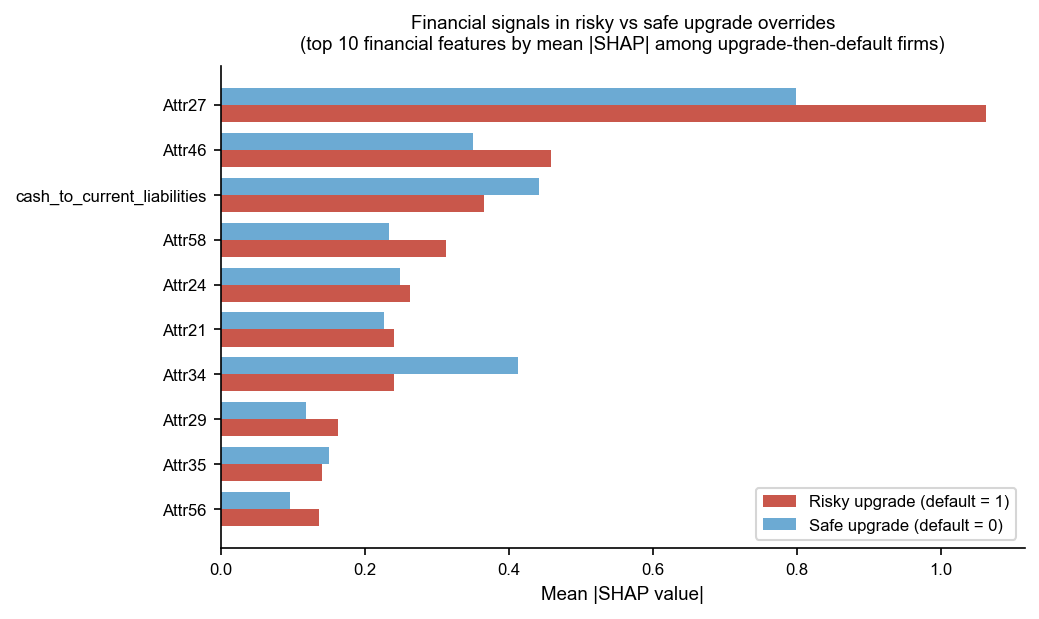

Saved: 26_shap_risky_upgrade_top10.png
Default rate by grade transition (upgrade cases, n ≥ 20):
transition    n  default_rate
  CCC → BB  372      0.196237
   CCC → B  902      0.174058
   B → BBB  481      0.095634
    B → BB 1127      0.092280
    BB → A  437      0.052632
  BB → BBB 1011      0.048467
   A → AAA  132      0.030303
  BBB → AA  330      0.027273
    A → AA  324      0.021605
   BBB → A  762      0.011811
  AA → AAA  233      0.004292
 AAA → AAA  157      0.000000


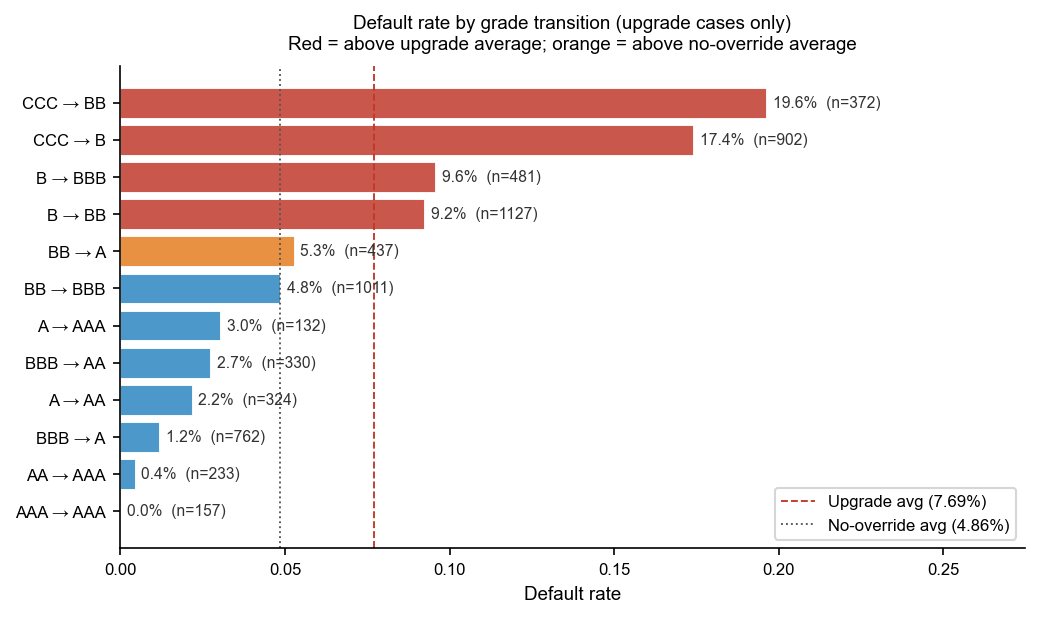

Saved: 27_grade_transition_default_rate.png
Upgrade-group avg default rate : 0.0769
No-override avg default rate   : 0.0486
Features selected for profile comparison: ['Attr27', 'Attr46', 'cash_to_current_liabilities', 'Attr58', 'Attr24', 'Attr21']

Median comparison — risky vs safe upgrade groups:
                    feature  risky_median  safe_median  pct_diff
                     Attr27      1.084100     0.741590      46.2
                     Attr46      0.503055     0.822155     -38.8
cash_to_current_liabilities    -40.866500   -16.827000    -142.9
                     Attr58      0.985680     0.974420       1.2
                     Attr24      0.004995     0.095803     -94.8
                     Attr21      1.045200     1.045200       0.0


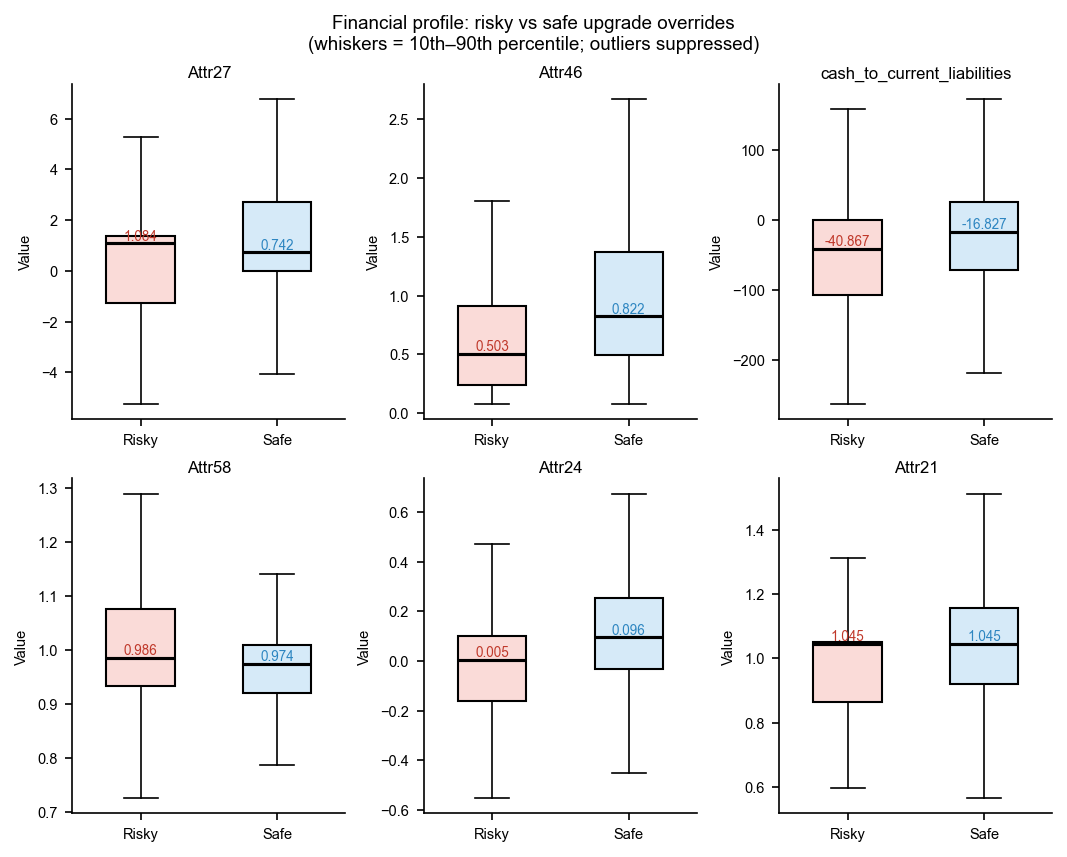

Saved: 28_financial_signal_comparison.png
=== Top 10 Financial Signals in Risky Upgrade Cases ===


,Feature,Mean |SHAP| Risky,Mean |SHAP| Safe,Risky/Safe Ratio
1,Attr27,1.0631,0.7983,1.3317
2,Attr46,0.4586,0.3500,1.3102
3,cash_to_current_liabilities,0.3661,0.4419,0.8285
4,Attr58,0.3131,0.2331,1.3431
5,Attr24,0.2630,0.2491,1.0557
6,Attr21,0.2408,0.2259,1.0661
7,Attr34,0.2398,0.4125,0.5813
8,Attr29,0.1619,0.1177,1.3764
9,Attr35,0.1405,0.1507,0.9324
10,Attr56,0.1356,0.0958,1.4156


Saved: NB11_pattern_summary.csv
Saved: NB11_transition_summary.csv

=== Discussion §5.2 — draft paragraph (auto-generated) ===

Although this study cannot identify which evaluators exhibit optimistic
bias—because the dataset contains no evaluator-level identifiers or
qualitative reasoning records—SHAP decompositions of risky upgrade cases
(upgrade override followed by actual default) reveal a consistent pattern
of financial distress signals that were systematically present but did not
prevent the evaluator's upgrade decision. The three financial features most
strongly associated with risky upgrades are Attr27,
Attr46, and cash_to_current_liabilities (Figure 26). These signals are
measurably more pronounced in firms that were upgraded and subsequently
defaulted compared with firms that were upgraded and survived.

Furthermore, the default risk of upgrade overrides varies considerably by
grade transition. The highest-risk transitions are CCC → BB,
CCC → B, and B → BBB, with the CCC → BB 

In [1]:
# NB11_evaluator_pattern_analysis.ipynb

# %% [markdown]
# # NB11 – Evaluator Override Pattern Analysis
# **Research Question:** What financial signals are systematically present
# in risky upgrade cases but overlooked by evaluators?
#
# Three analyses are conducted:
#
# | Analysis | Question                                          | Output |
# |----------|---------------------------------------------------|--------|
# | A        | Which financial signals concentrate in risky upgrades? | Fig 26 |
# | B        | Which grade transitions carry the highest default risk? | Fig 27 |
# | C        | How do financial profiles differ between risky and safe upgrades? | Fig 28 |
#
# **Input (identical to NB06 / NB07):**
# - `data/processed/override_data.parquet`
# - `models/xgboost/xgb_override.pkl`
#
# **Output:**
# - `results/figures/26_shap_risky_upgrade_top10.png`
# - `results/figures/27_grade_transition_default_rate.png`
# - `results/figures/28_financial_signal_comparison.png`
# - `results/tables/NB11_pattern_summary.csv`
# - `results/tables/NB11_transition_summary.csv`

# %%
import os
import warnings
import joblib
import inspect
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb_lib
import shap
import shap.explainers._tree as _shap_tree

warnings.filterwarnings("ignore")
np.random.seed(2024)

# ── Paths (consistent with NB06 / NB07) ──────────────────────────────────
PROC_DIR  = "../data/processed/"
MODEL_DIR = "../models/xgboost/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"
os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# ── Plot style (journal-ready: Arial, 600 dpi) ────────────────────────────
DPI = 600
plt.rcParams.update({
    "font.family"      : "Arial",
    "font.size"        : 9,
    "axes.titlesize"   : 10,
    "axes.labelsize"   : 9,
    "xtick.labelsize"  : 8,
    "ytick.labelsize"  : 8,
    "legend.fontsize"  : 8,
    "figure.dpi"       : 150,      # screen preview
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# ── SHAP compatibility patch for XGBoost >= 3.x ──────────────────────────
# XGBoost 3.x stores base_score as '[5E-1]' in save_config().
# SHAP 0.49.x has two conversion lines that fail:
#   Line A (older SHAP): self.base_score = float(learner_model_param["base_score"])
#   Line B (newer SHAP): base_score = float(learner_model_param["base_score"])
# Both must be patched.

import inspect, importlib
import shap.explainers._tree as _shap_tree

src_path = inspect.getfile(_shap_tree)
print(f"Patching: {src_path}")

with open(src_path, "r", encoding="utf-8") as f:
    src = f.read()

# Patch A — older pattern (self.base_score)
OLD_A = 'self.base_score = float(learner_model_param["base_score"])'
NEW_A = 'self.base_score = float(str(learner_model_param["base_score"]).strip("[]"))'

# Patch B — newer pattern (local variable base_score) ← XGBoost 3.x hits this
OLD_B = 'base_score = float(learner_model_param["base_score"])'
NEW_B = 'base_score = float(str(learner_model_param["base_score"]).strip("[]"))'

patched = False

if OLD_A in src and NEW_A not in src:
    src = src.replace(OLD_A, NEW_A)
    patched = True
    print("Patch A applied (self.base_score).")

if OLD_B in src and NEW_B not in src:
    src = src.replace(OLD_B, NEW_B)
    patched = True
    print("Patch B applied (base_score local variable).")

if patched:
    with open(src_path, "w", encoding="utf-8") as f:
        f.write(src)
    importlib.reload(_shap_tree)
    importlib.reload(shap.explainers._tree)
    importlib.reload(shap)
    import shap
    print("Module reloaded. Patches active.")
else:
    print("All patches already applied — no change needed.")

print(f"XGBoost : {xgb_lib.__version__}")
print(f"SHAP    : {shap.__version__}")

# %% [markdown]
# ## 1. Load Data and Model

# %%
# ── Load dataset (output of NB04) ────────────────────────────────────────
df = pd.read_parquet(PROC_DIR + "override_data.parquet")
print(f"Dataset shape : {df.shape}")
print(f"Default rate  : {df['default'].mean():.4f}")
print(f"\nOverride direction counts:")
print(df["override_direction"].value_counts())

# ── Load trained XGBoost model and feature list (output of NB06) ─────────
artifact     = joblib.load(MODEL_DIR + "xgb_override.pkl")
xgb_clf      = artifact["model"]
FEATURE_COLS = artifact["feature_cols"]

# Fill missing values with zero, consistent with NB06
X = df[FEATURE_COLS].fillna(0)
print(f"\nFeature count : {len(FEATURE_COLS)}")
print(f"X shape       : {X.shape}")

# %% [markdown]
# ## 2. Compute SHAP Values
# Uses the same TreeExplainer approach as NB07.
# Computed over the full dataset so that subgroup decompositions
# are directly comparable to the global results in NB07.

# %%
explainer   = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Expected value    : {explainer.expected_value:.4f}")

# Build a SHAP dataframe for subgroup analysis (mirrors NB07 §6)
shap_df = pd.DataFrame(shap_values, columns=FEATURE_COLS, index=X.index)
shap_df["override_direction"] = df["override_direction"].values
shap_df["default"]            = df["default"].values

# %% [markdown]
# ## 3. Define Analysis Segments
#
# | Segment       | Condition                                             | Interpretation              |
# |---------------|-------------------------------------------------------|-----------------------------|
# | Risky upgrade | override_direction == "upgrade" AND default == 1     | Upgraded, then defaulted    |
# | Safe upgrade  | override_direction == "upgrade" AND default == 0     | Upgraded, then survived     |
# | No override   | override_direction == "none"                          | Maintained grade (baseline) |
#
# Comparing risky and safe upgrade groups isolates the financial signals
# that distinguish harmful from benign upgrade decisions.

# %%
mask_risky = (df["override_direction"] == "upgrade") & (df["default"] == 1)
mask_safe  = (df["override_direction"] == "upgrade") & (df["default"] == 0)
mask_none  = (df["override_direction"] == "none")
mask_up    = (df["override_direction"] == "upgrade")

print("Segment summary:")
print(f"  All upgrades   : {mask_up.sum():,}  "
      f"(default rate = {df.loc[mask_up,   'default'].mean():.4f})")
print(f"  Risky upgrades : {mask_risky.sum():,}  "
      f"({mask_risky.sum() / mask_up.sum():.2%} of upgrades → defaulted)")
print(f"  Safe upgrades  : {mask_safe.sum():,}  "
      f"({mask_safe.sum()  / mask_up.sum():.2%} of upgrades → survived)")
print(f"  No override    : {mask_none.sum():,}  "
      f"(default rate = {df.loc[mask_none, 'default'].mean():.4f})")

# Extract SHAP value subsets for each segment
shap_risky = shap_values[mask_risky.values]   # shape: (N_risky, n_features)
shap_safe  = shap_values[mask_safe.values]    # shape: (N_safe,  n_features)
shap_none  = shap_values[mask_none.values]    # shape: (N_none,  n_features)

# %% [markdown]
# ## 4. Analysis A — Financial Signals Overlooked by Evaluators
#
# For each feature, compute mean |SHAP| separately for the risky and safe
# upgrade groups. Features with substantially higher mean |SHAP| in the
# risky group represent financial distress signals that were present at the
# time of the override decision but did not prevent the evaluator's upgrade.
#
# Override-specific variables (pd_system, grade_ordinal, grade_diff,
# override_flag) are excluded so that the comparison focuses on pure
# financial signals.

# %%
# Mean absolute SHAP per feature for each segment
mean_abs_risky = np.abs(shap_risky).mean(axis=0)
mean_abs_safe  = np.abs(shap_safe).mean(axis=0)

# Build comparison dataframe
shap_compare = pd.DataFrame({
    "feature"          : FEATURE_COLS,
    "mean_abs_risky"   : mean_abs_risky,
    "mean_abs_safe"    : mean_abs_safe,
    # Ratio > 1 indicates the signal is more prominent in risky upgrades
    "risky_safe_ratio" : mean_abs_risky / (mean_abs_safe + 1e-9),
}).sort_values("mean_abs_risky", ascending=False).reset_index(drop=True)

# Exclude override-derived variables; retain financial features only
OVERRIDE_VARS = {"pd_system", "grade_ordinal", "grade_diff", "override_flag"}
fin_compare = shap_compare[~shap_compare["feature"].isin(OVERRIDE_VARS)]

# Top 10 financial features ranked by mean |SHAP| in risky upgrades
top10_fin = fin_compare.head(10).copy()

print("Top 10 financial features by mean |SHAP| in risky upgrade cases:")
print(top10_fin[["feature", "mean_abs_risky",
                  "mean_abs_safe", "risky_safe_ratio"]].to_string(index=False))

# %%
# ── Figure 26: SHAP comparison — risky vs safe upgrade groups ─────────────
fig, ax = plt.subplots(figsize=(7.0, 4.2))

y_pos  = np.arange(len(top10_fin))
bar_w  = 0.38
feats  = top10_fin["feature"].tolist()

# Risky upgrade bars (red)
ax.barh(y_pos + bar_w / 2, top10_fin["mean_abs_risky"],
        height=bar_w, color="#C0392B", alpha=0.85,
        label="Risky upgrade (default = 1)")

# Safe upgrade bars (blue)
ax.barh(y_pos - bar_w / 2, top10_fin["mean_abs_safe"],
        height=bar_w, color="#2E86C1", alpha=0.70,
        label="Safe upgrade (default = 0)")

ax.set_yticks(y_pos)
ax.set_yticklabels(feats, fontsize=8)
ax.set_xlabel("Mean |SHAP value|", fontsize=9)
ax.set_title(
    "Financial signals in risky vs safe upgrade overrides\n"
    "(top 10 financial features by mean |SHAP| among upgrade-then-default firms)",
    fontsize=9, pad=8)
ax.legend(loc="lower right", fontsize=8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR + "26_shap_risky_upgrade_top10.png",
            dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 26_shap_risky_upgrade_top10.png")

# %% [markdown]
# ## 5. Analysis B — Default Rate by Grade Transition
#
# Among upgrade override cases, decompose default rates by specific
# grade transition (e.g., B → BB, CCC → B). This identifies which
# transitions carry disproportionate residual default risk, indicating
# where evaluator optimism is most consequential.
#
# Transitions with fewer than 20 observations are excluded for
# statistical stability.

# %%
# Restrict to upgrade cases only
df_up = df[df["override_direction"] == "upgrade"].copy()

# Construct transition label: system grade → final grade
df_up["transition"] = df_up["system_grade"] + " → " + df_up["final_grade"]

# Aggregate default rate and count per transition
trans_stats = (
    df_up.groupby("transition")["default"]
         .agg(n="count", default_rate="mean")
         .reset_index()
         .sort_values("default_rate", ascending=False)
)

# Apply minimum observation threshold
trans_stats = trans_stats[trans_stats["n"] >= 20].copy()

print("Default rate by grade transition (upgrade cases, n ≥ 20):")
print(trans_stats.to_string(index=False))

# %%
# ── Figure 27: Default rate by grade transition ───────────────────────────
DR_UPGRADE = df[df["override_direction"] == "upgrade"]["default"].mean()
DR_NONE    = df[df["override_direction"] == "none"]["default"].mean()

# Show top 12 riskiest transitions
top_trans = trans_stats.head(12)

# Colour coding:
#   red    = above upgrade-group average (most dangerous)
#   orange = above no-override baseline but below upgrade average
#   blue   = below no-override baseline
colors = [
    "#C0392B" if r > DR_UPGRADE
    else "#E67E22" if r > DR_NONE
    else "#2E86C1"
    for r in top_trans["default_rate"]
]

fig, ax = plt.subplots(figsize=(7.0, 4.2))

bars = ax.barh(top_trans["transition"], top_trans["default_rate"],
               color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)

# Reference lines
ax.axvline(DR_UPGRADE, color="#C0392B", linestyle="--", linewidth=0.9,
           label=f"Upgrade avg ({DR_UPGRADE:.2%})")
ax.axvline(DR_NONE,    color="#555555", linestyle=":",  linewidth=0.9,
           label=f"No-override avg ({DR_NONE:.2%})")

# Annotate bars with default rate and sample size
for bar, (_, row) in zip(bars, top_trans.iterrows()):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{row['default_rate']:.1%}  (n={int(row['n'])})",
            va="center", fontsize=7.5, color="#333333")

ax.set_xlabel("Default rate", fontsize=9)
ax.set_title(
    "Default rate by grade transition (upgrade cases only)\n"
    "Red = above upgrade average; orange = above no-override average",
    fontsize=9, pad=8)
ax.legend(fontsize=8, loc="lower right")
ax.invert_yaxis()
ax.set_xlim(0, top_trans["default_rate"].max() * 1.40)

plt.tight_layout()
plt.savefig(FIG_DIR + "27_grade_transition_default_rate.png",
            dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 27_grade_transition_default_rate.png")
print(f"Upgrade-group avg default rate : {DR_UPGRADE:.4f}")
print(f"No-override avg default rate   : {DR_NONE:.4f}")

# %% [markdown]
# ## 6. Analysis C — Financial Profile: Risky vs Safe Upgrades
#
# For the top financial features identified in Analysis A,
# compare the distribution of raw financial values between the
# risky and safe upgrade groups using box plots.
#
# Features where the risky group shows materially worse values
# (e.g., lower profitability, higher leverage) represent actionable
# signals for evaluator training and rating committee review protocols.

# %%
# Use the top 6 financial features from Analysis A
fin_feats = top10_fin["feature"].tolist()[:6]
print(f"Features selected for profile comparison: {fin_feats}")

df_risky_rows = df[mask_risky].copy()
df_safe_rows  = df[mask_safe].copy()

# Median comparison table
med_summary = pd.DataFrame({
    "feature"      : fin_feats,
    "risky_median" : [df_risky_rows[f].median() for f in fin_feats],
    "safe_median"  : [df_safe_rows[f].median()  for f in fin_feats],
})
med_summary["pct_diff"] = (
    (med_summary["risky_median"] - med_summary["safe_median"])
    / (med_summary["safe_median"].abs() + 1e-9) * 100
).round(1)

print("\nMedian comparison — risky vs safe upgrade groups:")
print(med_summary.to_string(index=False))

# %%
# ── Figure 28: Box plots — risky vs safe upgrade groups ──────────────────
n_feat = len(fin_feats)
ncols  = 3
nrows  = (n_feat + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(7.0, 2.8 * nrows),
                          constrained_layout=True)
axes_flat = axes.flatten() if n_feat > 1 else [axes]

for idx, feat in enumerate(fin_feats):
    ax = axes_flat[idx]

    risky_vals = df_risky_rows[feat].dropna()
    safe_vals  = df_safe_rows[feat].dropna()

    bp = ax.boxplot(
        [risky_vals, safe_vals],
        labels=["Risky", "Safe"],
        patch_artist=True,
        showfliers=False,                                   # hide extreme outliers
        medianprops=dict(color="black",   linewidth=1.5),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor("#FADBD8")   # light red  — risky
    bp["boxes"][1].set_facecolor("#D6EAF8")   # light blue — safe

    # Annotate median values
    ax.text(1, risky_vals.median(),
            f"{risky_vals.median():.3f}", ha="center", va="bottom",
            fontsize=6.5, color="#C0392B")
    ax.text(2, safe_vals.median(),
            f"{safe_vals.median():.3f}", ha="center", va="bottom",
            fontsize=6.5, color="#2E86C1")

    ax.set_title(feat, fontsize=8, pad=3)
    ax.set_ylabel("Value", fontsize=7)
    ax.tick_params(labelsize=7)

# Hide any unused subplots
for j in range(n_feat, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    "Financial profile: risky vs safe upgrade overrides\n"
    "(whiskers = 10th–90th percentile; outliers suppressed)",
    fontsize=9)

plt.savefig(FIG_DIR + "28_financial_signal_comparison.png",
            dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 28_financial_signal_comparison.png")

# %% [markdown]
# ## 7. Summary Tables

# %%
# Table: top 10 financial signals in risky upgrade cases
out_table = top10_fin[["feature", "mean_abs_risky",
                        "mean_abs_safe", "risky_safe_ratio"]].copy()
out_table.columns = ["Feature", "Mean |SHAP| Risky",
                     "Mean |SHAP| Safe", "Risky/Safe Ratio"]
out_table = out_table.round(4).reset_index(drop=True)
out_table.index += 1

print("=== Top 10 Financial Signals in Risky Upgrade Cases ===")
display(out_table)

out_table.to_csv(TABLE_DIR + "NB11_pattern_summary.csv")
print("Saved: NB11_pattern_summary.csv")

# Table: default rate by grade transition
trans_stats.to_csv(TABLE_DIR + "NB11_transition_summary.csv", index=False)
print("Saved: NB11_transition_summary.csv")

# %% [markdown]
# ## 8. Auto-generate Discussion §5.2 Draft
#
# Run this cell after completing Analyses A–C.
# The output is a paper-ready paragraph with actual feature names
# and transition labels substituted automatically.
# Copy the printed text into Discussion §5.2 and adjust wording as needed.

# %%
top3_feats = top10_fin["feature"].tolist()[:3]
top3_trans = trans_stats.head(3)["transition"].tolist()
top_dr     = trans_stats.iloc[0]["default_rate"]
top_tr     = trans_stats.iloc[0]["transition"]

draft = f"""
=== Discussion §5.2 — draft paragraph (auto-generated) ===

Although this study cannot identify which evaluators exhibit optimistic
bias—because the dataset contains no evaluator-level identifiers or
qualitative reasoning records—SHAP decompositions of risky upgrade cases
(upgrade override followed by actual default) reveal a consistent pattern
of financial distress signals that were systematically present but did not
prevent the evaluator's upgrade decision. The three financial features most
strongly associated with risky upgrades are {top3_feats[0]},
{top3_feats[1]}, and {top3_feats[2]} (Figure 26). These signals are
measurably more pronounced in firms that were upgraded and subsequently
defaulted compared with firms that were upgraded and survived.

Furthermore, the default risk of upgrade overrides varies considerably by
grade transition. The highest-risk transitions are {top3_trans[0]},
{top3_trans[1]}, and {top3_trans[2]}, with the {top_tr} transition
exhibiting a default rate of {top_dr:.1%}—substantially above the
upgrade-group average of {DR_UPGRADE:.1%} (Figure 27). These findings
suggest that rating committee scrutiny should be particularly concentrated
on upgrade decisions in these specific transitions and for firms exhibiting
the financial distress signatures identified above, providing a structured
basis for pre-finalisation review grounded in observable financial evidence.
"""

print(draft)

# %% [markdown]
# ## 9. Environment

# %%
import sys, sklearn
print(f"Python  : {sys.version.split()[0]}")
print(f"XGBoost : {xgb_lib.__version__}")
print(f"SHAP    : {shap.__version__}")
print(f"sklearn : {sklearn.__version__}")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")